In [5]:
from google.colab import files

uploaded = files.upload()

Saving crop_yield.csv to crop_yield (1).csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('crop_yield.csv')

df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [8]:
df.shape

(19689, 10)

In [9]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [11]:
df.isnull().sum()

,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Production,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


In [12]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [13]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

df['Crop'] = le_crop.fit_transform(df['Crop'])
df['Season'] = le_season.fit_transform(df['Season'])
df['State'] = le_state.fit_transform(df['State'])

In [14]:
X = df[['Crop',
        'Crop_Year',
        'Season',
        'State',
        'Area',
        'Production',
        'Annual_Rainfall',
        'Fertilizer',
        'Pesticide']]

y = df['Yield']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
predictions = model.predict(X_test)

print(predictions[:5])

[4.65483048 1.20951923 6.65635267 1.03780199 0.57408829]


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.9066185276698813
Mean Absolute Error: 10.430858457238354


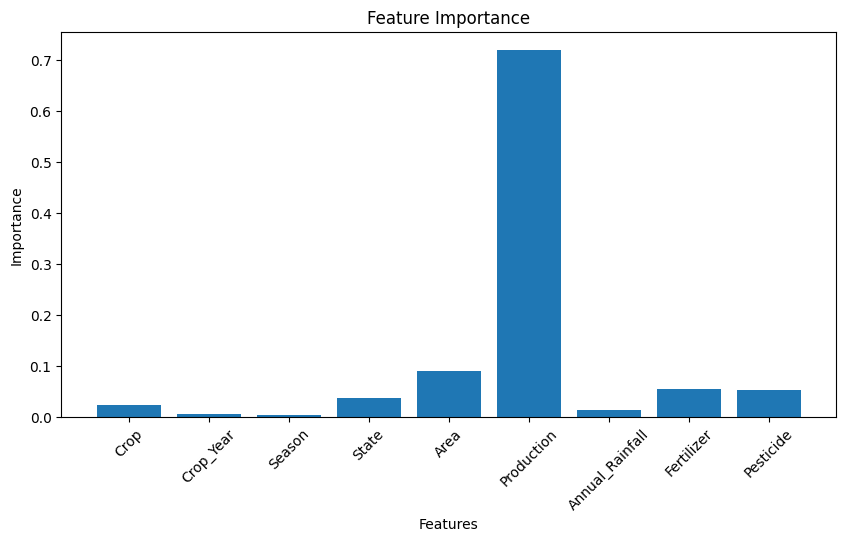

In [19]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

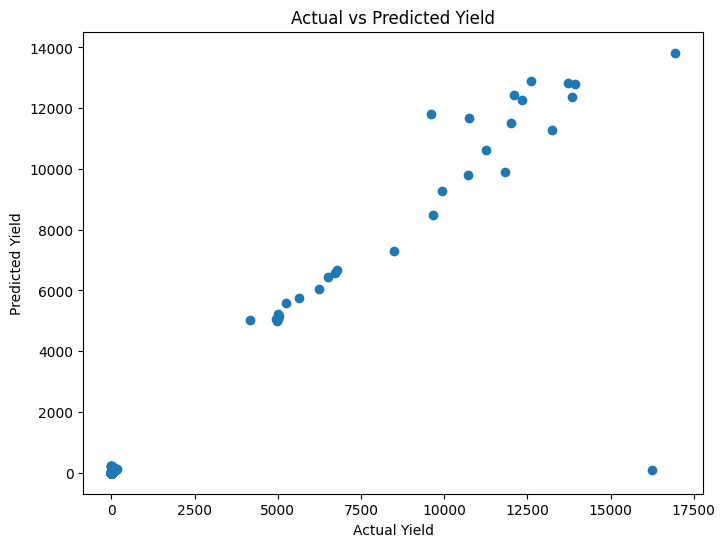

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

In [21]:
import joblib

joblib.dump(model, "crop_yield_model.pkl")

['crop_yield_model.pkl']

In [22]:
from google.colab import files

files.download("crop_yield_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>